In [1]:
import pandas as pd

In [2]:
movie_data = pd.read_csv("imdb_top_1000.csv")
person_data = pd.read_csv("people_stats.csv")
person_data.head(3)

,Name,IMDB,Meta,Votes,Gross,Movie_Count
0,Aamir Bashir,8.10,77.93,73891.0,23530892.0,1
1,Aamir Khan,8.24,75.50,145744.5,7107876.5,8
2,Aaron Eckhart,9.00,84.00,2303232.0,534858444.0,1


In [3]:
movie_data = movie_data[["Series_Title", "Meta_score", "IMDB_Rating", "Director", "Star1", "Star2", "Star3", "Star4", "No_of_Votes", "Gross"]]
movie_data.head(3)

,Series_Title,Meta_score,IMDB_Rating,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,80.0,9.3,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,The Godfather,100.0,9.2,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,The Dark Knight,84.0,9.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


In [4]:
person_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3202 entries, 0 to 3201
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         3202 non-null   object 
 1   IMDB         3202 non-null   float64
 2   Meta         3202 non-null   float64
 3   Votes        3202 non-null   float64
 4   Gross        3202 non-null   float64
 5   Movie_Count  3202 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 150.2+ KB


In [5]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Series_Title  1000 non-null   object 
 1   Meta_score    843 non-null    float64
 2   IMDB_Rating   1000 non-null   float64
 3   Director      1000 non-null   object 
 4   Star1         1000 non-null   object 
 5   Star2         1000 non-null   object 
 6   Star3         1000 non-null   object 
 7   Star4         1000 non-null   object 
 8   No_of_Votes   1000 non-null   int64  
 9   Gross         831 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 78.2+ KB


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


person_stats = person_data.rename(columns={
    'IMDB': 'Avg_IMDB',
    'Meta': 'Avg_Meta',
    'Votes': 'Avg_Votes',
    'Gross': 'Avg_Gross'
}).groupby('Name').mean().reset_index()
try:

    movie_data['Gross'] = movie_data['Gross'].str.replace('[^\d.]', '', regex=True)


    movie_data['Gross'] = movie_data['Gross'].astype(float)

    movie_data['Meta_score'] = movie_data['Meta_score'].fillna(movie_data['Meta_score'].median())
    movie_data['Gross'] = movie_data['Gross'].fillna(movie_data['Gross'].median())
except:
    print("Processed")
    

def merge_person_stats(df, role):
    return (df.merge(person_stats, left_on=role, right_on='Name', how='left')
            .rename(columns={
                'Avg_IMDB': f'{role}_Avg_IMDB',
                'Avg_Votes': f'{role}_Avg_Votes',
                'Avg_Gross': f'{role}_Avg_Gross',
                'Movie_Count': f'{role}_Movie_Count'
            })
            .drop(columns=['Name', 'Avg_Meta']))  

movie_data = merge_person_stats(movie_data, 'Director')
for star in ['Star1', 'Star2', 'Star3', 'Star4']:
    movie_data = merge_person_stats(movie_data, star)
star_metrics = ['Avg_IMDB', 'Avg_Votes', 'Avg_Gross', 'Movie_Count']
for metric in star_metrics:
    star_cols = [f'{star}_{metric}' for star in ['Star1', 'Star2', 'Star3', 'Star4']]
    movie_data[f'Stars_{metric}'] = movie_data[star_cols].mean(axis=1)

features = [
    'Meta_score',
    'No_of_Votes',
    'Gross',
    'Director_Avg_IMDB', 'Director_Avg_Votes', 'Director_Avg_Gross', 'Director_Movie_Count',
    'Stars_Avg_IMDB', 'Stars_Avg_Votes', 'Stars_Avg_Gross', 'Stars_Movie_Count'
]

X = movie_data[features]
y = movie_data['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"- MSE: {mse:.4f}")
print(f"- R²: {r2:.4f}")

results = pd.DataFrame({
    'Movie': movie_data.loc[X_test.index, 'Series_Title'],
    'Actual': y_test,
    'Predicted': y_pred,
    'Difference': np.abs(y_test - y_pred)
}).sort_values('Difference', ascending=False)
print(len(results))
print("\nTop 10 predictions with largest errors:")
print(results.head(10))

Model Performance:
- MSE: 0.0079
- R²: 0.8767
200

Top 10 predictions with largest errors:
                                                 Movie  Actual  Predicted  \
879                   Once Upon a Time... in Hollywood     7.6      8.004   
59                                   Avengers: Endgame     8.4      8.042   
865                              The Magnificent Seven     7.7      8.004   
60                              Avengers: Infinity War     8.4      8.111   
218                                          Spotlight     8.1      7.834   
737                Captain America: The Winter Soldier     7.7      7.952   
635                                      Walk the Line     7.8      8.015   
974                            The Godfather: Part III     7.6      7.814   
78   Dr. Strangelove or: How I Learned to Stop Worr...     8.4      8.195   
66                                              WALL·E     8.4      8.583   

     Difference  
879       0.404  
59        0.358  
865    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results, alpha=0.6)
plt.plot([results['Actual'].min(), results['Actual'].max()], 
         [results['Actual'].min(), results['Actual'].max()], 
         'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted IMDB Ratings Sorted by Name', fontsize=14)
plt.xlabel('Actual IMDB Rating', fontsize=12)
plt.ylabel('Predicted IMDB Rating', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

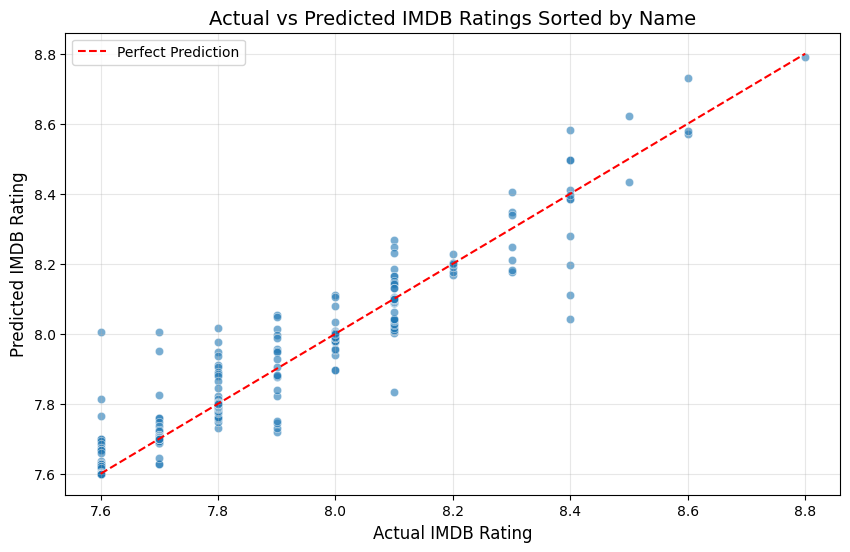

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results, alpha=0.6)
plt.plot([results['Actual'].min(), results['Actual'].max()], 
         [results['Actual'].min(), results['Actual'].max()], 
         'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted IMDB Ratings Sorted by Name', fontsize=14)
plt.xlabel('Actual IMDB Rating', fontsize=12)
plt.ylabel('Predicted IMDB Rating', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_31752\1715944959.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


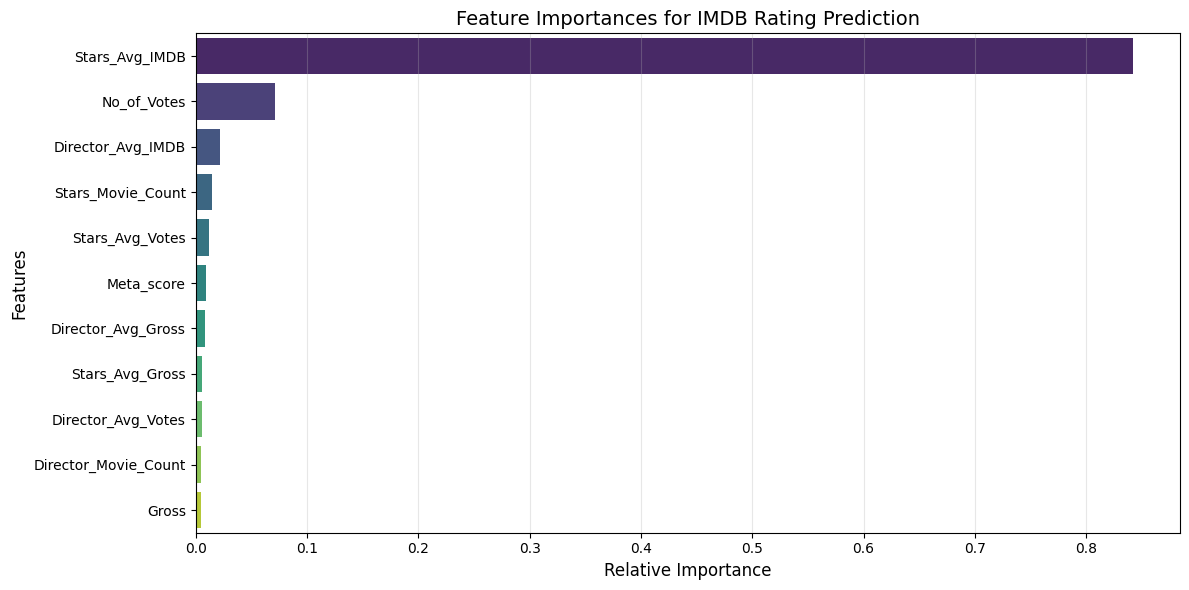

In [ ]:

importances = model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importances for IMDB Rating Prediction', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

person_stats = person_data.groupby('Name').agg({
    'IMDB': 'mean',
    'Votes': 'mean',
    'Gross': 'mean',
    'Movie_Count': 'mean'
}).reset_index()
person_stats.columns = ['Name', 'Avg_IMDB', 'Avg_Votes', 'Avg_Gross', 'Movie_Count']

movie_data['Gross'] = movie_data['Gross'].astype(float).fillna(movie_data['Gross'].median())
movie_data['Meta_score'] = movie_data['Meta_score'].fillna(movie_data['Meta_score'].median())

def merge_person_stats(df, role):
    merged = pd.merge(df, person_stats, left_on=role, right_on='Name', how='left')
    merged = merged.rename(columns={
        'Avg_IMDB': f'{role}_Avg_IMDB',
        'Avg_Votes': f'{role}_Avg_Votes',
        'Avg_Gross': f'{role}_Avg_Gross',
        'Movie_Count': f'{role}_Movie_Count'
    })
    return merged.drop(columns=['Name'])

movie_data = merge_person_stats(movie_data, 'Director')
for star in ['Star1', 'Star2', 'Star3', 'Star4']:
    movie_data = merge_person_stats(movie_data, star)

for metric in ['Avg_IMDB', 'Avg_Votes', 'Avg_Gross', 'Movie_Count']:
    cols = [f'Star1_{metric}', f'Star2_{metric}', f'Star3_{metric}', f'Star4_{metric}']
    movie_data[f'Stars_{metric}'] = movie_data[cols].mean(axis=1)

y = movie_data['IMDB_Rating']

X_director = movie_data[['Director_Avg_IMDB', 'Director_Avg_Votes', 'Director_Avg_Gross', 'Director_Movie_Count']]
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(X_director, y, test_size=0.2, random_state=42)

X_actor = movie_data[['Stars_Avg_IMDB', 'Stars_Avg_Votes', 'Stars_Avg_Gross', 'Stars_Movie_Count']]
X_train_act, X_test_act, y_train_act, y_test_act = train_test_split(X_actor, y, test_size=0.2, random_state=42)

model_dir = RandomForestRegressor(n_estimators=100, random_state=42)
model_dir.fit(X_train_dir, y_train_dir)
y_pred_dir = model_dir.predict(X_test_dir)

model_act = RandomForestRegressor(n_estimators=100, random_state=42)
model_act.fit(X_train_act, y_train_act)
y_pred_act = model_act.predict(X_test_act)

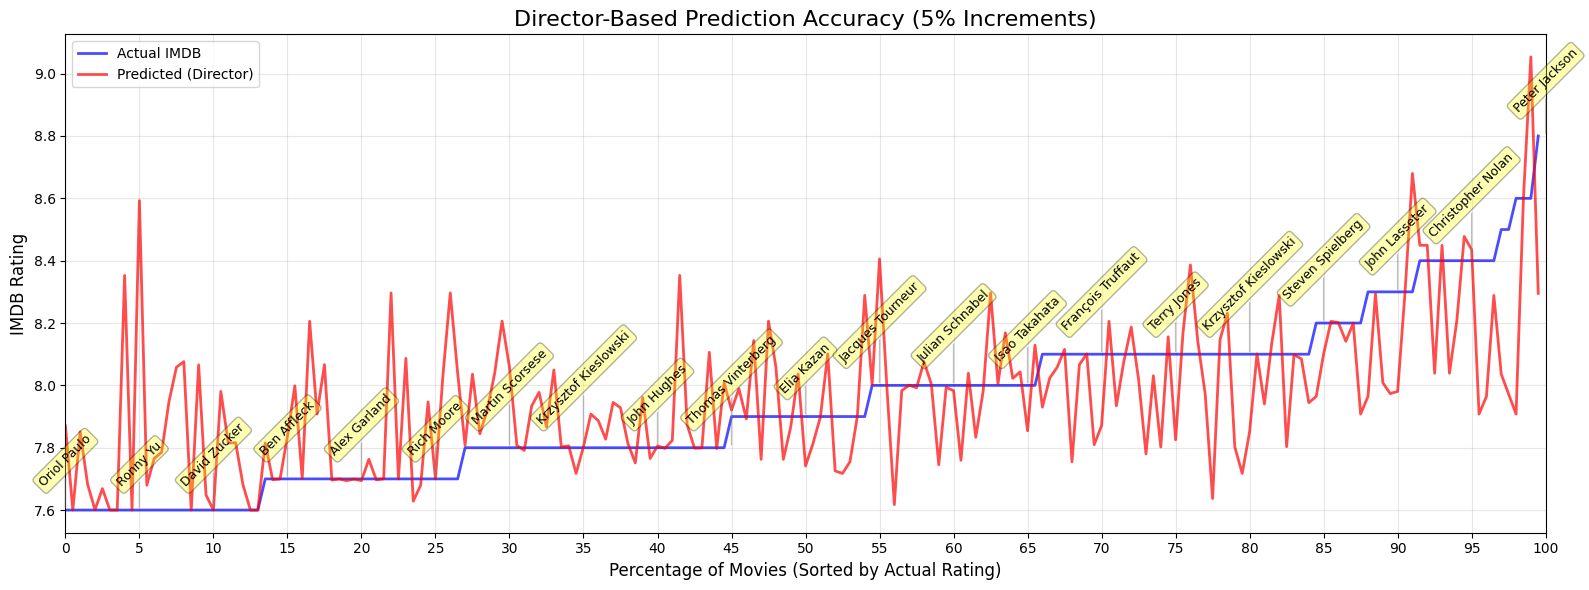

In [ ]:

results_dir = pd.DataFrame({
    'Movie': movie_data.loc[X_test_dir.index, 'Series_Title'],
    'Director': movie_data.loc[X_test_dir.index, 'Director'],
    'Actual': y_test_dir,
    'Predicted': y_pred_dir,
    'Difference': np.abs(y_test_dir - y_pred_dir)
}).sort_values('Actual').reset_index(drop=True)

x_normalized = results_dir.index / len(results_dir) * 100

plt.figure(figsize=(16, 6))
plt.plot(x_normalized, results_dir['Actual'], 'b-', alpha=0.7, label='Actual IMDB', linewidth=2)
plt.plot(x_normalized, results_dir['Predicted'], 'r-', alpha=0.7, label='Predicted (Director)', linewidth=2)

for pos in np.arange(0, 101, 5):  
    idx = int(pos / 100 * (len(results_dir) - 1))  
    plt.annotate(
        results_dir.loc[idx, 'Director'],
        xy=(pos, results_dir.loc[idx, 'Actual']),
        xytext=(0, 15), textcoords='offset points',
        ha='center', va='bottom', rotation=45, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5)
    )

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.xlabel("Percentage of Movies (Sorted by Actual Rating)", fontsize=12)
plt.ylabel("IMDB Rating", fontsize=12)
plt.title("Director-Based Prediction Accuracy (5% Increments)", fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

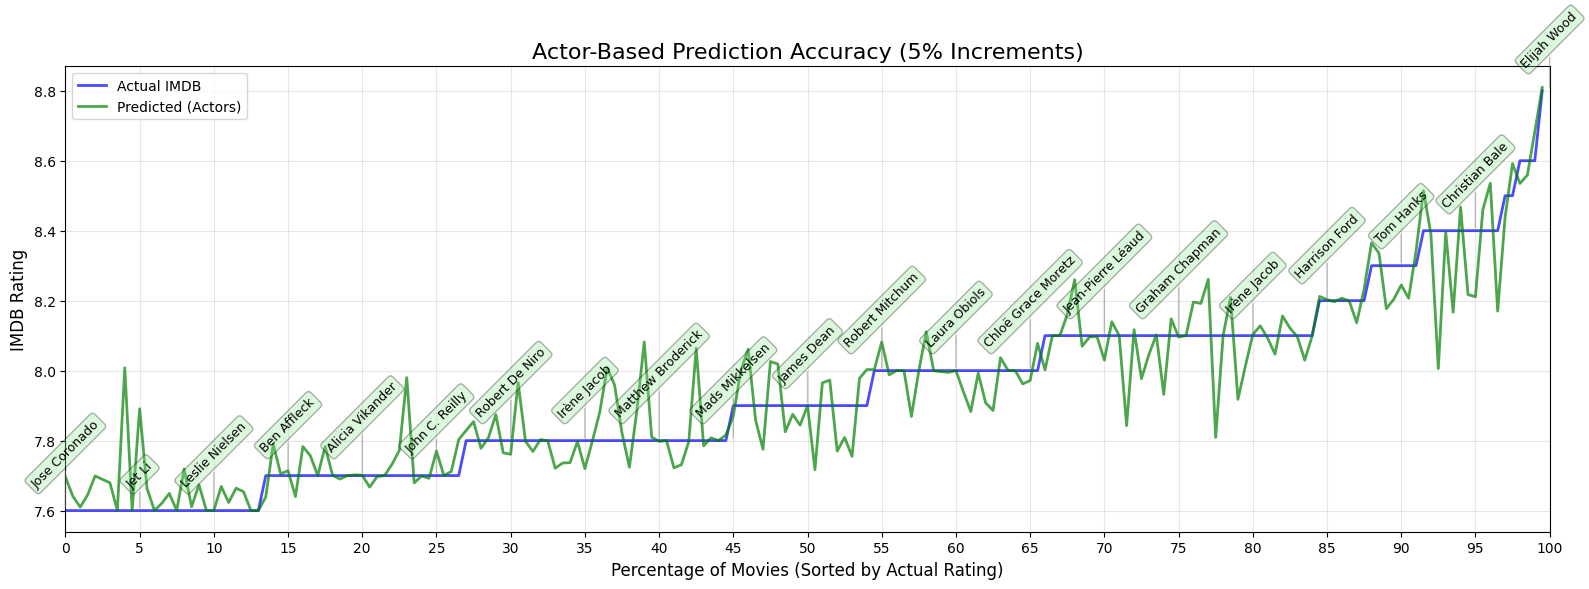

In [ ]:

results_act = pd.DataFrame({
    'Movie': movie_data.loc[X_test_act.index, 'Series_Title'],
    'Star1': movie_data.loc[X_test_act.index, 'Star1'],  
    'Actual': y_test_act,
    'Predicted': y_pred_act,
    'Difference': np.abs(y_test_act - y_pred_act)
}).sort_values('Actual').reset_index(drop=True)


x_normalized = results_act.index / len(results_act) * 100

plt.figure(figsize=(16, 6))
plt.plot(x_normalized, results_act['Actual'], 'b-', alpha=0.7, label='Actual IMDB', linewidth=2)
plt.plot(x_normalized, results_act['Predicted'], 'g-', alpha=0.7, label='Predicted (Actors)', linewidth=2)

for pos in np.arange(0, 101, 5):
    idx = int(pos / 100 * (len(results_act) - 1))
    plt.annotate(
        results_act.loc[idx, 'Star1'],
        xy=(pos, results_act.loc[idx, 'Actual']),
        xytext=(0, 15), textcoords='offset points',
        ha='center', va='bottom', rotation=45, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', alpha=0.3),
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5)
    )

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.xlabel("Percentage of Movies (Sorted by Actual Rating)", fontsize=12)
plt.ylabel("IMDB Rating", fontsize=12)
plt.title("Actor-Based Prediction Accuracy (5% Increments)", fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()